#  Week 3 - Day 1: Machine Learning Fundamentals
**Student:** Shaik Arshiya Tabasum  
**Topic:** Machine Learning Workflow & Linear Regression  
**Assignment:** Build a Student Performance Prediction Model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
import pandas as pd # Ensure pandas is imported

# Load the dataset
df = pd.read_csv('student_performance.csv')

# Basic exploration
print("=== Dataset Shape:", df.shape)
print("\n=== First 5 Rows:")
display(df.head()) # Use display() for better output in Colab

=== Dataset Shape: (40, 6)

=== First 5 Rows:


,StudentID,StudyHours,AttendancePercent,PreviousScore,ParentalSupport,ExamScore
0,1,2.5,75,55,1,58
1,2,5.0,90,70,2,76
2,3,1.0,60,40,0,42
3,4,7.0,95,85,2,91
4,5,3.5,80,62,1,65


In [7]:
# Check for missing values
print("=== Missing Values:")
print(df.isnull().sum())

print("\n=== Basic Statistics:")
df.describe()

=== Missing Values:
StudentID            0
StudyHours           0
AttendancePercent    0
PreviousScore        0
ParentalSupport      0
ExamScore            0
dtype: int64

=== Basic Statistics:


,StudentID,StudyHours,AttendancePercent,PreviousScore,ParentalSupport,ExamScore
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,4.012500,79.775000,64.125000,1.200000,67.550000
std,11.690452,2.335587,14.155705,18.101123,0.757865,19.248643
min,1.000000,0.000000,45.000000,25.000000,0.000000,27.000000
25%,10.750000,2.000000,71.750000,52.500000,1.000000,54.500000
50%,20.500000,4.000000,82.500000,67.500000,1.000000,69.500000
75%,30.250000,6.000000,91.000000,78.250000,2.000000,83.250000
max,40.000000,8.500000,98.000000,92.000000,2.000000,97.000000


In [8]:
# Define Features (X) and Label (y)
X = df[['StudyHours', 'AttendancePercent', 'PreviousScore', 'ParentalSupport']]
y = df['ExamScore']

print("Features (X) shape:", X.shape)
print("Label (y) shape:", y.shape)
print("\nFeature columns:", list(X.columns))
print("Label column: ExamScore")

Features (X) shape: (40, 4)
Label (y) shape: (40,)

Feature columns: ['StudyHours', 'AttendancePercent', 'PreviousScore', 'ParentalSupport']
Label column: ExamScore


In [9]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples     : {len(df)}")
print(f"Training samples  : {len(X_train)} (80%)")
print(f"Testing samples   : {len(X_test)} (20%)")

Total samples     : 40
Training samples  : 32 (80%)
Testing samples   : 8 (20%)


In [10]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:20s}: {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

✅ Model trained successfully!

Model Coefficients:
  StudyHours          : 1.1535
  AttendancePercent   : 0.1067
  PreviousScore       : 0.7688
  ParentalSupport     : 1.7470

Intercept: 3.0707


In [11]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred.round(1),
    'Difference': (y_test.values - y_pred).round(1)
})
print("=== Actual vs Predicted Comparison:")
print(comparison.to_string(index=False))

=== Actual vs Predicted Comparison:
 Actual Score  Predicted Score  Difference
           66             66.7        -0.7
           93             93.1        -0.1
           27             27.1        -0.1
           45             44.6         0.4
           65             65.1        -0.1
           87             87.0        -0.0
           69             69.8        -0.8
           90             90.8        -0.8


In [12]:
# Predict for brand new students
new_students = pd.DataFrame({
    'StudyHours':        [3.0, 6.5, 1.0],
    'AttendancePercent': [78,  92,  55 ],
    'PreviousScore':     [60,  85,  35 ],
    'ParentalSupport':   [1,   2,   0  ]
})

new_predictions = model.predict(new_students)

print("=== Predictions for New Students:")
print("-" * 40)
for i, score in enumerate(new_predictions):
    print(f"Student {i+1}: Predicted Exam Score = {score:.1f}")

=== Predictions for New Students:
----------------------------------------
Student 1: Predicted Exam Score = 62.7
Student 2: Predicted Exam Score = 89.2
Student 3: Predicted Exam Score = 37.0


In [13]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE (Mean Absolute Error) : {mae:.2f}")
print(f"  R² Score                  : {r2:.4f}")
print("=" * 40)

if r2 >= 0.9:
    print("\n🌟 Excellent model performance!")
elif r2 >= 0.7:
    print("\n✅ Good model performance!")
else:
    print("\n⚠️ Model needs improvement.")

       MODEL EVALUATION RESULTS
  MAE (Mean Absolute Error) : 0.37
  R² Score                  : 0.9995

🌟 Excellent model performance!


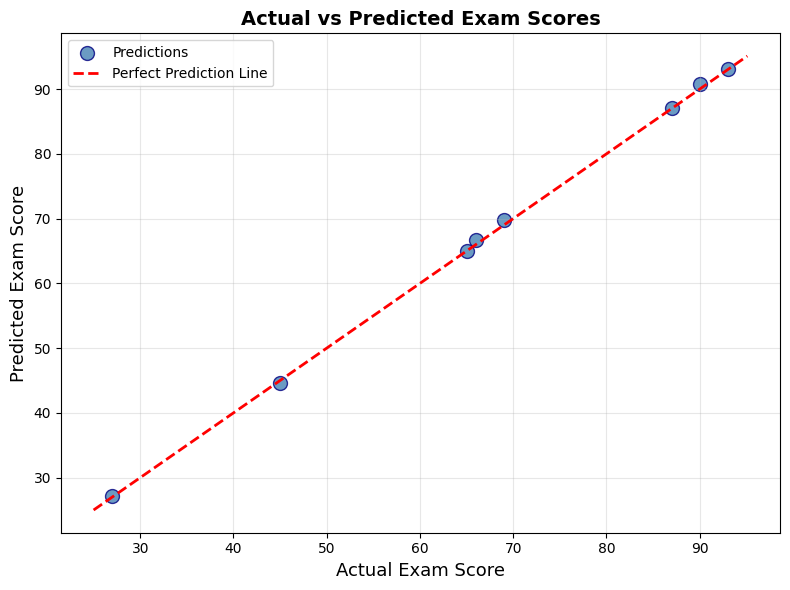

✅ Chart saved!


In [15]:
import os

# Visualization 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='navy', s=100, alpha=0.8, label='Predictions')
mn = min(y_test.min(), y_pred.min()) - 2
mx = max(y_test.max(), y_pred.max()) + 2
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Exam Score', fontsize=13)
plt.ylabel('Predicted Exam Score', fontsize=13)
plt.title('Actual vs Predicted Exam Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Create the 'screenshots' directory if it doesn't exist
os.makedirs('screenshots', exist_ok=True)

plt.savefig('screenshots/actual_vs_predicted.png', dpi=150)
plt.show()
print("✅ Chart saved!")

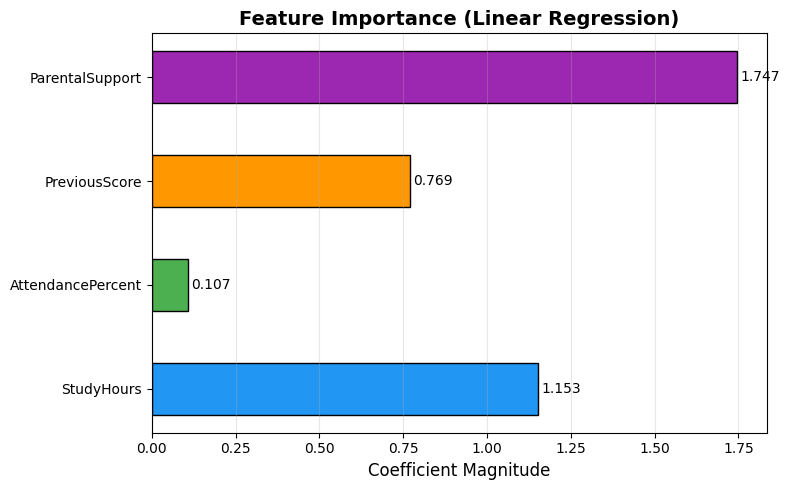

✅ Chart saved!


In [16]:
# Visualization 2: Feature Importance
plt.figure(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = plt.barh(X.columns, np.abs(model.coef_), color=colors, edgecolor='black', height=0.5)
plt.xlabel('Coefficient Magnitude', fontsize=12)
plt.title('Feature Importance (Linear Regression)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, np.abs(model.coef_)):
    plt.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/feature_importance.png', dpi=150)
plt.show()
print("✅ Chart saved!")

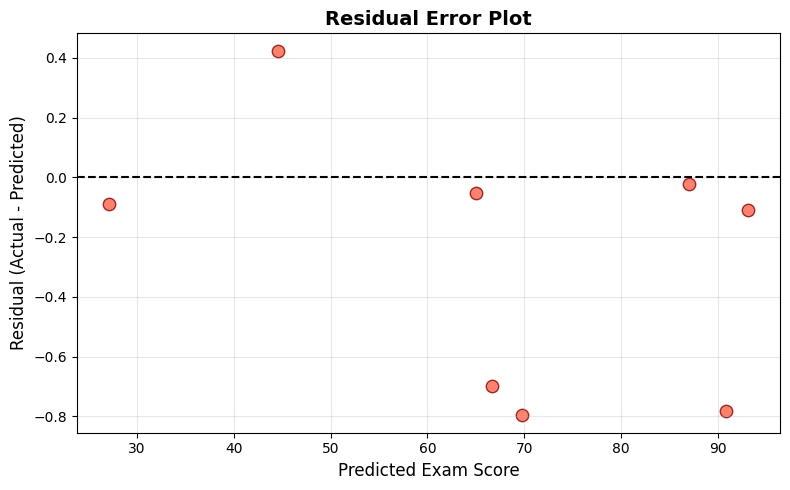

✅ Chart saved!


In [17]:
# Visualization 3: Residual Plot
residuals = y_test.values - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='tomato', edgecolors='darkred', s=80, alpha=0.8)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Exam Score', fontsize=12)
plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
plt.title('Residual Error Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/residual_plot.png', dpi=150)
plt.show()
print("✅ Chart saved!")

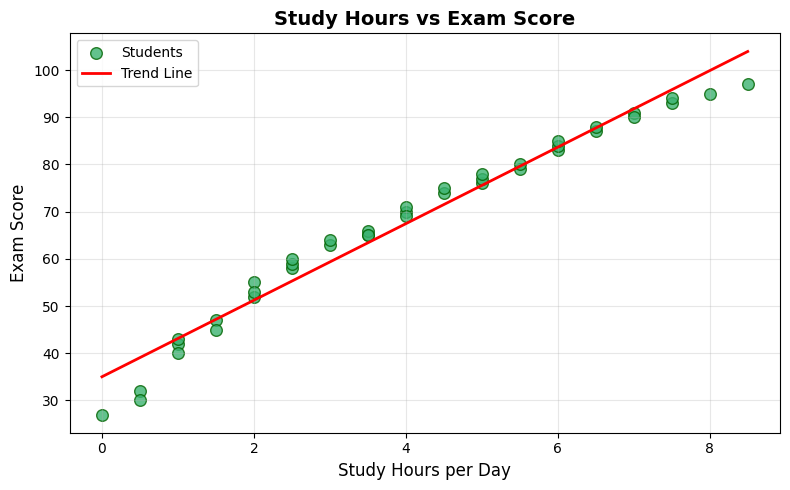

✅ Chart saved!


In [18]:
# Visualization 4: Study Hours vs Exam Score
plt.figure(figsize=(8, 5))
plt.scatter(df['StudyHours'], df['ExamScore'], color='mediumseagreen', edgecolors='darkgreen', s=70, alpha=0.8, label='Students')
m, b = np.polyfit(df['StudyHours'], df['ExamScore'], 1)
x_line = np.linspace(df['StudyHours'].min(), df['StudyHours'].max(), 100)
plt.plot(x_line, m*x_line + b, 'r-', linewidth=2, label='Trend Line')
plt.xlabel('Study Hours per Day', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Study Hours vs Exam Score', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('screenshots/studyhours_vs_score.png', dpi=150)
plt.show()
print("✅ Chart saved!")